In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Check system hardware state
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing DeepMind Candidate Pipeline on Architecture: {device}")

Executing DeepMind Candidate Pipeline on Architecture: cpu


In [2]:
class PhysicsInformedNN(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=50, output_dim=1):
        super(PhysicsInformedNN, self).__init__()
        # Using Tanh activations because equations require smooth, continuous derivatives
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x, t):
        # Bind inputs together to evaluate coordinates
        X = torch.cat([x, t], dim=1)
        return self.net(X)

In [3]:
def compute_physics_loss(model, x_collocation, t_collocation, wave_speed=1.0):
    # Enable gradient tracking on raw coordinates for Autograd pass
    x_collocation.requires_grad_(True)
    t_collocation.requires_grad_(True)

    # Forward Pass
    u = model(x_collocation, t_collocation)

    # Compute first-order partial derivatives via automatic differentiation
    u_x = torch.autograd.grad(u, x_collocation, torch.ones_like(u), create_graph=True)[0]
    u_t = torch.autograd.grad(u, t_collocation, torch.ones_like(u), create_graph=True)[0]

    # Compute second-order physical derivatives
    u_xx = torch.autograd.grad(u_x, x_collocation, torch.ones_like(u_x), create_graph=True)[0]
    u_tt = torch.autograd.grad(u_t, t_collocation, torch.ones_like(u_t), create_graph=True)[0]

    # Governing Wave Equation Physics Residual: u_tt - c^2 * u_xx = 0
    physics_residual = u_tt - (wave_speed ** 2) * u_xx

    # Mean Squared Error of physical non-compliance
    return torch.mean(physics_residual ** 2)

In [4]:
def generate_training_data():
    # 1. Boundary Initial Conditions: At t = 0, u(x,0) = sin(pi * x)
    x_init = np.linspace(-1, 1, 100)[:, None]
    t_init = np.zeros_like(x_init)
    u_init = np.sin(np.pi * x_init)

    # 2. Dirichlet Boundary Conditions: u(-1, t) = 0 and u(1, t) = 0
    t_boundary = np.linspace(0, 1, 100)[:, None]
    x_bound_left = -np.ones_like(t_boundary)
    x_bound_right = np.ones_like(t_boundary)
    u_bound = np.zeros_like(t_boundary)

    # Concatenate boundary groups into tensors
    X_b = np.vstack([np.hstack([x_init, t_init]), np.hstack([x_bound_left, t_boundary]), np.hstack([x_bound_right, t_boundary])])
    y_b = np.vstack([u_init, u_bound, u_bound])

    # 3. Unsupervised Collocation Points across domain spaces
    x_collo = np.random.uniform(-1, 1, (2000, 1))
    t_collo = np.random.uniform(0, 1, (2000, 1))

    return (torch.FloatTensor(X_b[:, 0:1]).to(device),
            torch.FloatTensor(X_b[:, 1:2]).to(device),
            torch.FloatTensor(y_b).to(device),
            torch.FloatTensor(x_collo).to(device),
            torch.FloatTensor(t_collo).to(device))

x_b, t_b, u_b, x_c, t_c = generate_training_data()

In [5]:
model = PhysicsInformedNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("="*55)
print("   PINN SYSTEM CONVERGENCE: SOLVING PARTIAL DIFFERENTIALS   ")
print("="*55)

for epoch in range(1501):
    # Supervised Boundary Ingestion Loss
    u_pred_b = model(x_b, t_b)
    loss_boundary = torch.mean((u_pred_b - u_b) ** 2)

    # Unsupervised Embedded Physics Equation Loss
    loss_physics = compute_physics_loss(model, x_c, t_c, wave_speed=1.0)

    # Combined Loss Balance Formulation
    total_loss = loss_boundary + loss_physics

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    if epoch % 300 == 0:
        print(f"Epoch {epoch:04d} | Boundary Loss: {loss_boundary.item():.5f} | Physics Residual Loss: {loss_physics.item():.5f} | Total: {total_loss.item():.5f}")

print("="*55)

   PINN SYSTEM CONVERGENCE: SOLVING PARTIAL DIFFERENTIALS   
Epoch 0000 | Boundary Loss: 0.15570 | Physics Residual Loss: 0.00043 | Total: 0.15613
Epoch 0300 | Boundary Loss: 0.02650 | Physics Residual Loss: 0.00020 | Total: 0.02670
Epoch 0600 | Boundary Loss: 0.02466 | Physics Residual Loss: 0.00040 | Total: 0.02506
Epoch 0900 | Boundary Loss: 0.00204 | Physics Residual Loss: 0.00081 | Total: 0.00286
Epoch 1200 | Boundary Loss: 0.00092 | Physics Residual Loss: 0.00027 | Total: 0.00119
Epoch 1500 | Boundary Loss: 0.00054 | Physics Residual Loss: 0.00012 | Total: 0.00065


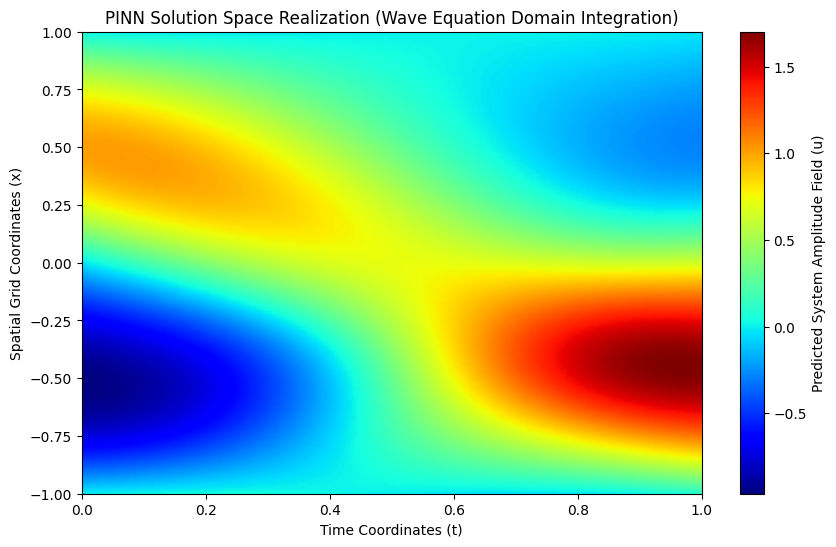

In [6]:
# Build spatial validation domain array spaces
x_space = np.linspace(-1, 1, 200)
t_space = np.linspace(0, 1, 200)
X, T = np.meshgrid(x_space, t_space)

x_flat = torch.FloatTensor(X.flatten()[:, None]).to(device)
t_flat = torch.FloatTensor(T.flatten()[:, None]).to(device)

model.eval()
with torch.no_grad():
    u_surface = model(x_flat, t_flat).cpu().numpy().reshape(X.shape)

# Render spatial phase profile
plt.figure(figsize=(10, 6))
plt.pcolormesh(T, X, u_surface, shading='gouraud', cmap='jet')
plt.colorbar(label='Predicted System Amplitude Field (u)')
plt.xlabel('Time Coordinates (t)')
plt.ylabel('Spatial Grid Coordinates (x)')
plt.title('PINN Solution Space Realization (Wave Equation Domain Integration)')
plt.show()